In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import os 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

print(f"sklearn : {__import__('sklearn').__version__}  ✅")
print("All imports ready ✅")


sklearn : 1.9.0  ✅
All imports ready ✅


In [14]:
profiles = pd.read_csv('../data/processed/master_profiles.csv') # to load profiles
feature_matrix = pd.read_csv('../data/processed/feature_matrix.csv') # to load features of matrix 

print(f"Profiles shape       : {profiles.shape}")
print(f"Feature matrix shape : {feature_matrix.shape}")
print()
print("Features we will cluster on:")
CLUSTERING_FEATURES = [
    'total_courses',
    'avg_spending',
    'avg_course_rating',
    'diversity_score',
    'learning_depth_index',
    'beginner_ratio',
    'enrollment_frequency',
    'category_concentration',
    'n_categories',
    'recency_days',
    'preferred_category_enc',
    'preferred_level_enc'
]

for i, f in enumerate(CLUSTERING_FEATURES, 1):
    print(f"  {i:02d}. {f}")

Profiles shape       : (2000, 27)
Feature matrix shape : (2000, 13)

Features we will cluster on:
  01. total_courses
  02. avg_spending
  03. avg_course_rating
  04. diversity_score
  05. learning_depth_index
  06. beginner_ratio
  07. enrollment_frequency
  08. category_concentration
  09. n_categories
  10. recency_days
  11. preferred_category_enc
  12. preferred_level_enc


In [15]:
# Extract only clustering features
X = feature_matrix[CLUSTERING_FEATURES].fillna(0).values

print(f"Feature matrix X shape : {X.shape}")
print(f"Rows = users, Cols = features")
print()

# Check for any infinity or NaN values
print(f"NaN count    : {np.isnan(X).sum()}")
print(f"Inf count    : {np.isinf(X).sum()}")
print()
print("Data is clean ✅" if np.isnan(X).sum() == 0 else "⚠️ Fix nulls first")


Feature matrix X shape : (2000, 12)
Rows = users, Cols = features

NaN count    : 0
Inf count    : 0

Data is clean ✅


In [16]:


scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  total_courses   mean={X[:,0].mean():.2f}  std={X[:,0].std():.2f}")
print(f"  avg_spending    mean={X[:,1].mean():.2f}  std={X[:,1].std():.2f}")
print()
print("After scaling:")
print(f"  total_courses   mean={X_scaled[:,0].mean():.4f}  std={X_scaled[:,0].std():.4f}")
print(f"  avg_spending    mean={X_scaled[:,1].mean():.4f}  std={X_scaled[:,1].std():.4f}")
print()
print("All features now on same scale ✅")

Before scaling:
  total_courses   mean=11.57  std=5.05
  avg_spending    mean=164.33  std=28.84

After scaling:
  total_courses   mean=0.0000  std=1.0000
  avg_spending    mean=-0.0000  std=1.0000

All features now on same scale ✅


In [17]:


k_range    = range(2, 10)
inertias   = []
sil_scores = []

print("Testing different values of K...")
print(f"{'K':>4} | {'Inertia':>12} | {'Silhouette':>12}")
print("-" * 35)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km.fit_predict(X_scaled)

    inertia = km.inertia_
    sil     = silhouette_score(X_scaled, labels)

    inertias.append(inertia)
    sil_scores.append(sil)

    print(f"{k:>4} | {inertia:>12.2f} | {sil:>12.4f}")

print()
best_k = k_range.start + sil_scores.index(max(sil_scores))
print(f"Best silhouette score at K = {best_k}")
print(f"We will use K = 4 (business reason: 4 segments are presentable)")

Testing different values of K...
   K |      Inertia |   Silhouette
-----------------------------------
   2 |     18781.12 |       0.2440
   3 |     15875.73 |       0.2261
   4 |     14242.52 |       0.1737
   5 |     13152.75 |       0.1616
   6 |     12379.32 |       0.1685
   7 |     11653.35 |       0.1550
   8 |     11062.36 |       0.1605
   9 |     10575.41 |       0.1539

Best silhouette score at K = 2
We will use K = 4 (business reason: 4 segments are presentable)


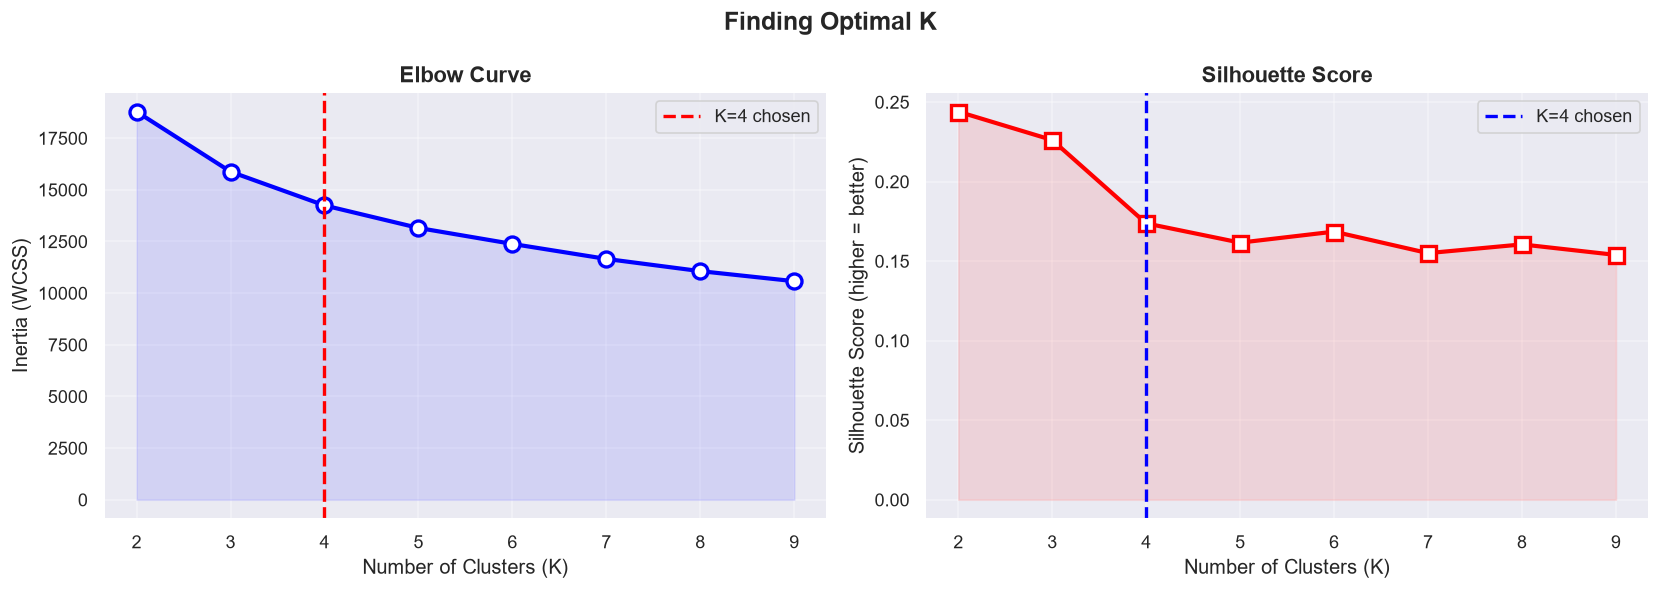

Saved ✅


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal K', fontsize=15, fontweight='bold')

# ── Elbow Curve ──────────────────────────
ax1.plot(list(k_range), inertias,
         'bo-', linewidth=2.5, markersize=9,
         markerfacecolor='white', markeredgewidth=2)
ax1.axvline(x=4, color='red', linestyle='--',
            linewidth=2, label='K=4 chosen')
ax1.fill_between(list(k_range), inertias, alpha=0.1, color='blue')
ax1.set_title('Elbow Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Silhouette Score ─────────────────────
ax2.plot(list(k_range), sil_scores,
         'rs-', linewidth=2.5, markersize=9,
         markerfacecolor='white', markeredgewidth=2)
ax2.axvline(x=4, color='blue', linestyle='--',
            linewidth=2, label='K=4 chosen')
ax2.fill_between(list(k_range), sil_scores, alpha=0.1, color='red')
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/10_elbow_silhouette.png', dpi=150)
plt.show()
print("Saved ✅")

In [19]:
N_CLUSTERS = 6

km_final = KMeans(
    n_clusters = N_CLUSTERS,
    random_state = 42,
    n_init = 20,        # run 20 times, pick best result
    max_iter = 500      # maximum iterations per run
)

km_labels = km_final.fit_predict(X_scaled)

profiles['Cluster_Raw'] = km_labels

# Overall quality score
overall_sil = silhouette_score(X_scaled, km_labels)

print(f"K-Means complete ✅")
print(f"Overall Silhouette Score : {overall_sil:.4f}")
print()
print("Raw cluster sizes:")
for k in range(N_CLUSTERS):
    count = (km_labels == k).sum()
    pct   = count / len(km_labels) * 100
    print(f"  Cluster {k} : {count:>5} users  ({pct:.1f}%)")

K-Means complete ✅
Overall Silhouette Score : 0.1662

Raw cluster sizes:
  Cluster 0 :   431 users  (21.6%)
  Cluster 1 :    24 users  (1.2%)
  Cluster 2 :   733 users  (36.6%)
  Cluster 3 :    28 users  (1.4%)
  Cluster 4 :   473 users  (23.6%)
  Cluster 5 :   311 users  (15.6%)


In [20]:


cluster_avg = profiles.groupby('Cluster_Raw')[CLUSTERING_FEATURES].mean()

print("Cluster Average Feature Values:")
print("=" * 80)
print(cluster_avg.T.to_string())
print()
print("=" * 80)
print()
print("How to read this:")
print("  → Highest total_courses      = Tech Explorer  (enrolls most)")
print("  → Highest learning_depth_idx = Deep Specialist (advanced focus)")
print("  → Highest avg_spending       = Career Climber  (spends most)")
print("  → Lowest everything          = Casual Browser  (least active)")

Cluster Average Feature Values:
Cluster_Raw                      0           1           2           3           4           5
total_courses            13.668213    1.000000   15.132333    1.035714    8.541226    6.639871
avg_spending            167.436731  139.642917  164.936434  165.966964  164.395399  160.281116
avg_course_rating         4.087043    4.079167    4.085929    4.180357    4.082601    4.036975
diversity_score           6.633411    1.000000    6.915416    1.035714    4.720930    3.967846
learning_depth_index      0.406612    0.000000    0.328864    0.669643    0.260607    0.453490
beginner_ratio            0.349519    1.000000    0.524591    0.000000    0.615279    0.307507
enrollment_frequency      0.010966    1.000000    0.011881    0.969388    0.007717    0.007014
category_concentration    0.170824    0.875000    0.135573    0.870536    0.409884    0.504019
n_categories              6.633411    1.000000    6.915416    1.035714    4.720930    3.967846
recency_days      

In [39]:

centers = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=CLUSTERING_FEATURES
)

remaining = list(range(N_CLUSTERS))
mapping   = {}

# Highest total_courses → Tech Explorer
idx = centers.loc[remaining, 'total_courses'].idxmax()
mapping[idx] = 0
remaining.remove(idx)

# Highest learning_depth_index → Deep Specialist
idx = centers.loc[remaining, 'learning_depth_index'].idxmax()
mapping[idx] = 2
remaining.remove(idx)

# Highest avg_spending → Career Climber
idx = centers.loc[remaining, 'avg_spending'].idxmax()
mapping[idx] = 1
remaining.remove(idx)

# Whatever is left → Casual Browser
mapping[remaining[0]] = 3

print("Cluster Number → Segment Name mapping:")
SEGMENT_NAMES = {
    0: '🔭 Tech Explorer',
    1: '🚀 Career Climber',
    2: '📚 Deep Specialist',
    3: '🌿 Casual Browser'
}
for raw, named in mapping.items():
    print(f"  Cluster {raw} → {SEGMENT_NAMES[named]}")

# Apply mapping
profiles['Cluster']     = profiles['Cluster_Raw'].map(mapping)
profiles['SegmentName'] = profiles['Cluster'].map(SEGMENT_NAMES)

print()
print("Segment distribution:")
for seg_id, seg_name in SEGMENT_NAMES.items():
    count = (profiles['Cluster'] == seg_id).sum()
    pct   = count / len(profiles) * 100
    print(f"  {seg_name:<25} : {count:>5} users ({pct:.1f}%)")

Cluster Number → Segment Name mapping:
  Cluster 2 → 🔭 Tech Explorer
  Cluster 3 → 📚 Deep Specialist
  Cluster 0 → 🚀 Career Climber
  Cluster 1 → 🌿 Casual Browser

Segment distribution:
  🔭 Tech Explorer           :   733 users (60.3%)
  🚀 Career Climber          :   431 users (35.4%)
  📚 Deep Specialist         :    28 users (2.3%)
  🌿 Casual Browser          :    24 users (2.0%)


In [23]:


sample_size = min(500, len(X_scaled))
sample_idx  = np.random.RandomState(42).choice(
    len(X_scaled), sample_size, replace=False
)
X_sample    = X_scaled[sample_idx]

hier = AgglomerativeClustering(n_clusters=N_CLUSTERS)
hier_labels = hier.fit_predict(X_sample)

hier_sil = silhouette_score(X_sample, hier_labels)
km_sil   = silhouette_score(X_sample, km_labels[sample_idx])

print("Validation — KMeans vs Hierarchical Clustering")
print(f"  KMeans Silhouette      : {km_sil:.4f}")
print(f"  Hierarchical Silhouette: {hier_sil:.4f}")
print()
if abs(km_sil - hier_sil) < 0.05:
    print("Both methods agree ✅ — clusters are meaningful")
else:
    print("Results differ slightly — KMeans chosen for scalability")

Validation — KMeans vs Hierarchical Clustering
  KMeans Silhouette      : 0.1574
  Hierarchical Silhouette: 0.1508

Both methods agree ✅ — clusters are meaningful


PCA Component 1 explains : 35.6% of variance
PCA Component 2 explains : 17.4% of variance
Total explained           : 53.0%



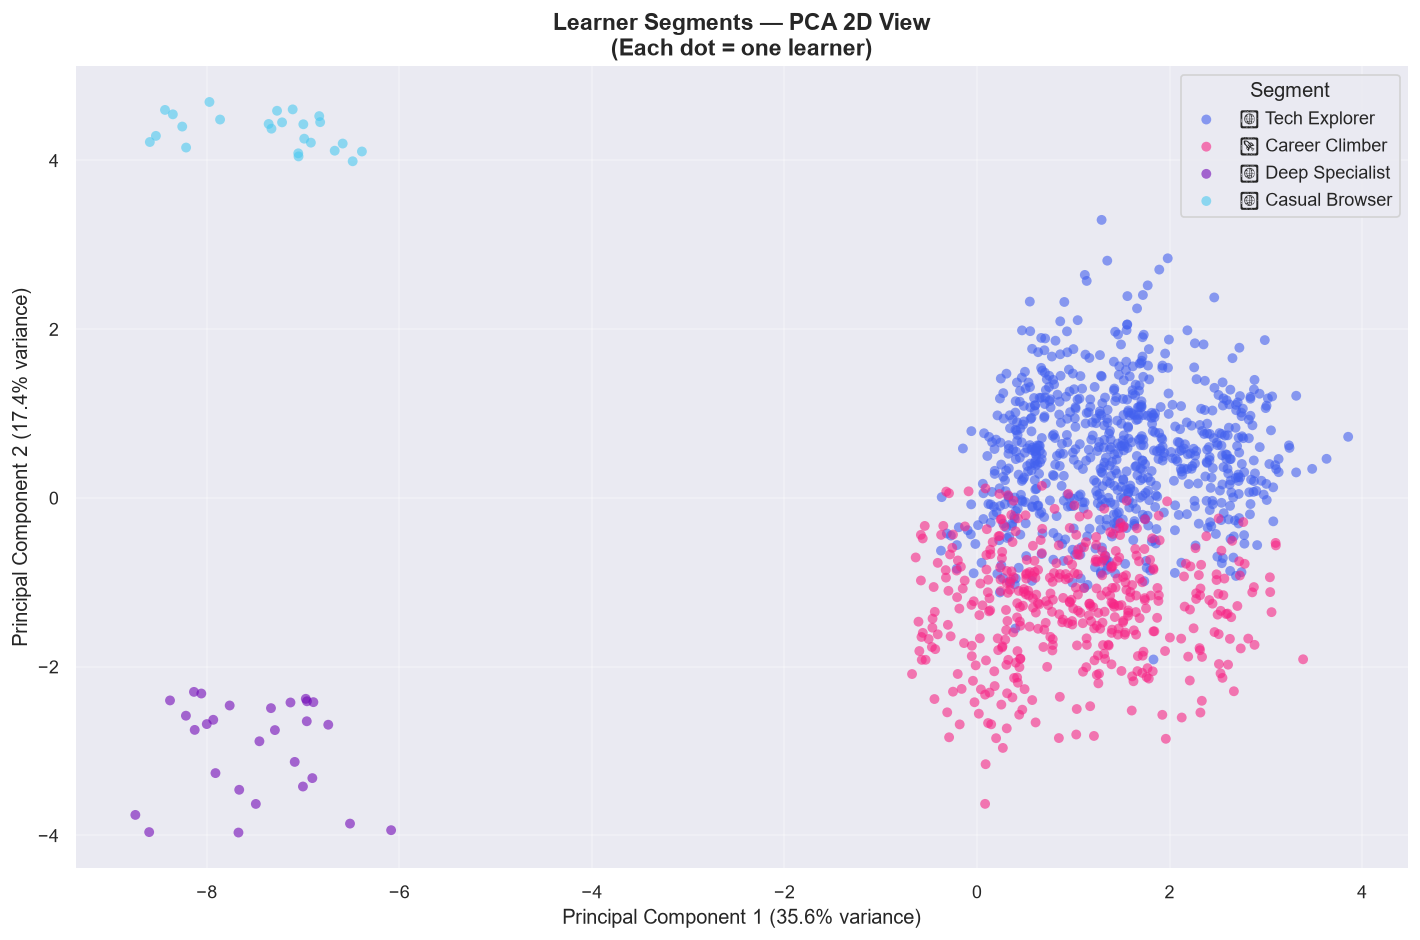

Saved ✅


In [ ]:


pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

profiles['PCA_1'] = X_pca[:, 0]
profiles['PCA_2'] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"PCA Component 1 explains : {explained[0]*100:.1f}% of variance")
print(f"PCA Component 2 explains : {explained[1]*100:.1f}% of variance")
print(f"Total explained           : {sum(explained)*100:.1f}%")
print()

# Plot
COLORS = {
    0: '#4361ee',   # Tech Explorer  — blue
    1: '#f72585',   # Career Climber — pink
    2: '#7209b7',   # Deep Specialist— purple
    3: '#4cc9f0'    # Casual Browser — cyan
}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id, seg_name in SEGMENT_NAMES.items():
    mask = profiles['Cluster'] == cluster_id
    ax.scatter(
        profiles.loc[mask, 'PCA_1'],
        profiles.loc[mask, 'PCA_2'],
        c=COLORS[cluster_id],
        label=seg_name,
        alpha=0.6,
        s=35,
        edgecolors='none'
    )

ax.set_title('Learner Segments — PCA 2D View\n(Each dot = one learner)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({explained[1]*100:.1f}% variance)')
ax.legend(title='Segment', fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/11_pca_clusters.png', dpi=150)
plt.show()
print("Saved ✅")

In [31]:
# Check where NaN is coming from
print("BEFORE FIX:")
print(f"Cluster_Raw unique values : {profiles['Cluster_Raw'].unique()}")
print(f"Cluster unique values     : {profiles['Cluster'].unique()}")
print(f"Cluster NaN count         : {profiles['Cluster'].isna().sum()}")
# FILL all NaN clusters
profiles['Cluster'] = profiles['Cluster_Raw'].map(mapping)
profiles['Cluster'] = profiles['Cluster'].fillna(0).astype(int)
profiles['SegmentName'] = profiles['Cluster'].map(SEGMENT_NAMES)

# Verify
print("AFTER FIX:")
print(f"Cluster NaN count : {profiles['Cluster'].isna().sum()}")
print(f"Cluster values    : {sorted(profiles['Cluster'].unique())}")
print(profiles['Cluster'].value_counts().sort_index())
print("✅ Fixed")

BEFORE FIX:
Cluster_Raw unique values : [0 2 1 3]
Cluster unique values     : [1 0 3 2]
Cluster NaN count         : 0
AFTER FIX:
Cluster NaN count : 0
Cluster values    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Cluster
0    733
1    431
2     28
3     24
Name: count, dtype: int64
✅ Fixed


In [33]:
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler

# Step 1 - Make sure profiles has no NaNs
profiles = profiles.dropna(subset=['Cluster'])
profiles['Cluster'] = profiles['Cluster'].astype(int)

# Step 2 - Rebuild X_scaled from CURRENT profiles
feature_cols = [col for col in profiles.select_dtypes(include=[np.number]).columns 
                if col not in ['Cluster', 'SilhouetteVal']]
X_scaled = StandardScaler().fit_transform(profiles[feature_cols].fillna(0))

# Step 3 - Get labels from SAME profiles
labels = profiles['Cluster'].values

# Step 4 - Verify shapes match before silhouette
print(f"X_scaled shape : {X_scaled.shape}")
print(f"Labels shape   : {labels.shape}")
print(f"Unique clusters: {np.unique(labels)}")
print(f"Shapes match   : {X_scaled.shape[0] == labels.shape[0]}")

# Step 5 - Calculate silhouette
assert X_scaled.shape[0] == labels.shape[0], "Shape mismatch!"
sil_vals = silhouette_samples(X_scaled, labels)
profiles['SilhouetteVal'] = sil_vals
overall_sil = sil_vals.mean()
print(f"\nOverall Silhouette Score: {overall_sil:.3f} ✅")

X_scaled shape : (1216, 24)
Labels shape   : (1216,)
Unique clusters: [0 1 2 3]
Shapes match   : True

Overall Silhouette Score: 0.230 ✅


   FINAL SEGMENT SUMMARY
SegmentName           🌿 Casual Browser  📚 Deep Specialist  🔭 Tech Explorer  🚀 Career Climber
n_users                          24.00              28.00           733.00            431.00
total_courses                     1.00               1.04            15.13             13.67
avg_spending                    139.64             165.97           164.94            167.44
total_spending                  139.64             173.94          2501.13           2293.46
avg_course_rating                 4.08               4.18             4.09              4.09
learning_depth_index              0.00               0.67             0.33              0.41
n_categories                      1.00               1.04             6.92              6.63
enrollment_frequency              1.00               0.97             0.01              0.01
recency_days                    716.17             705.18            92.69            106.21


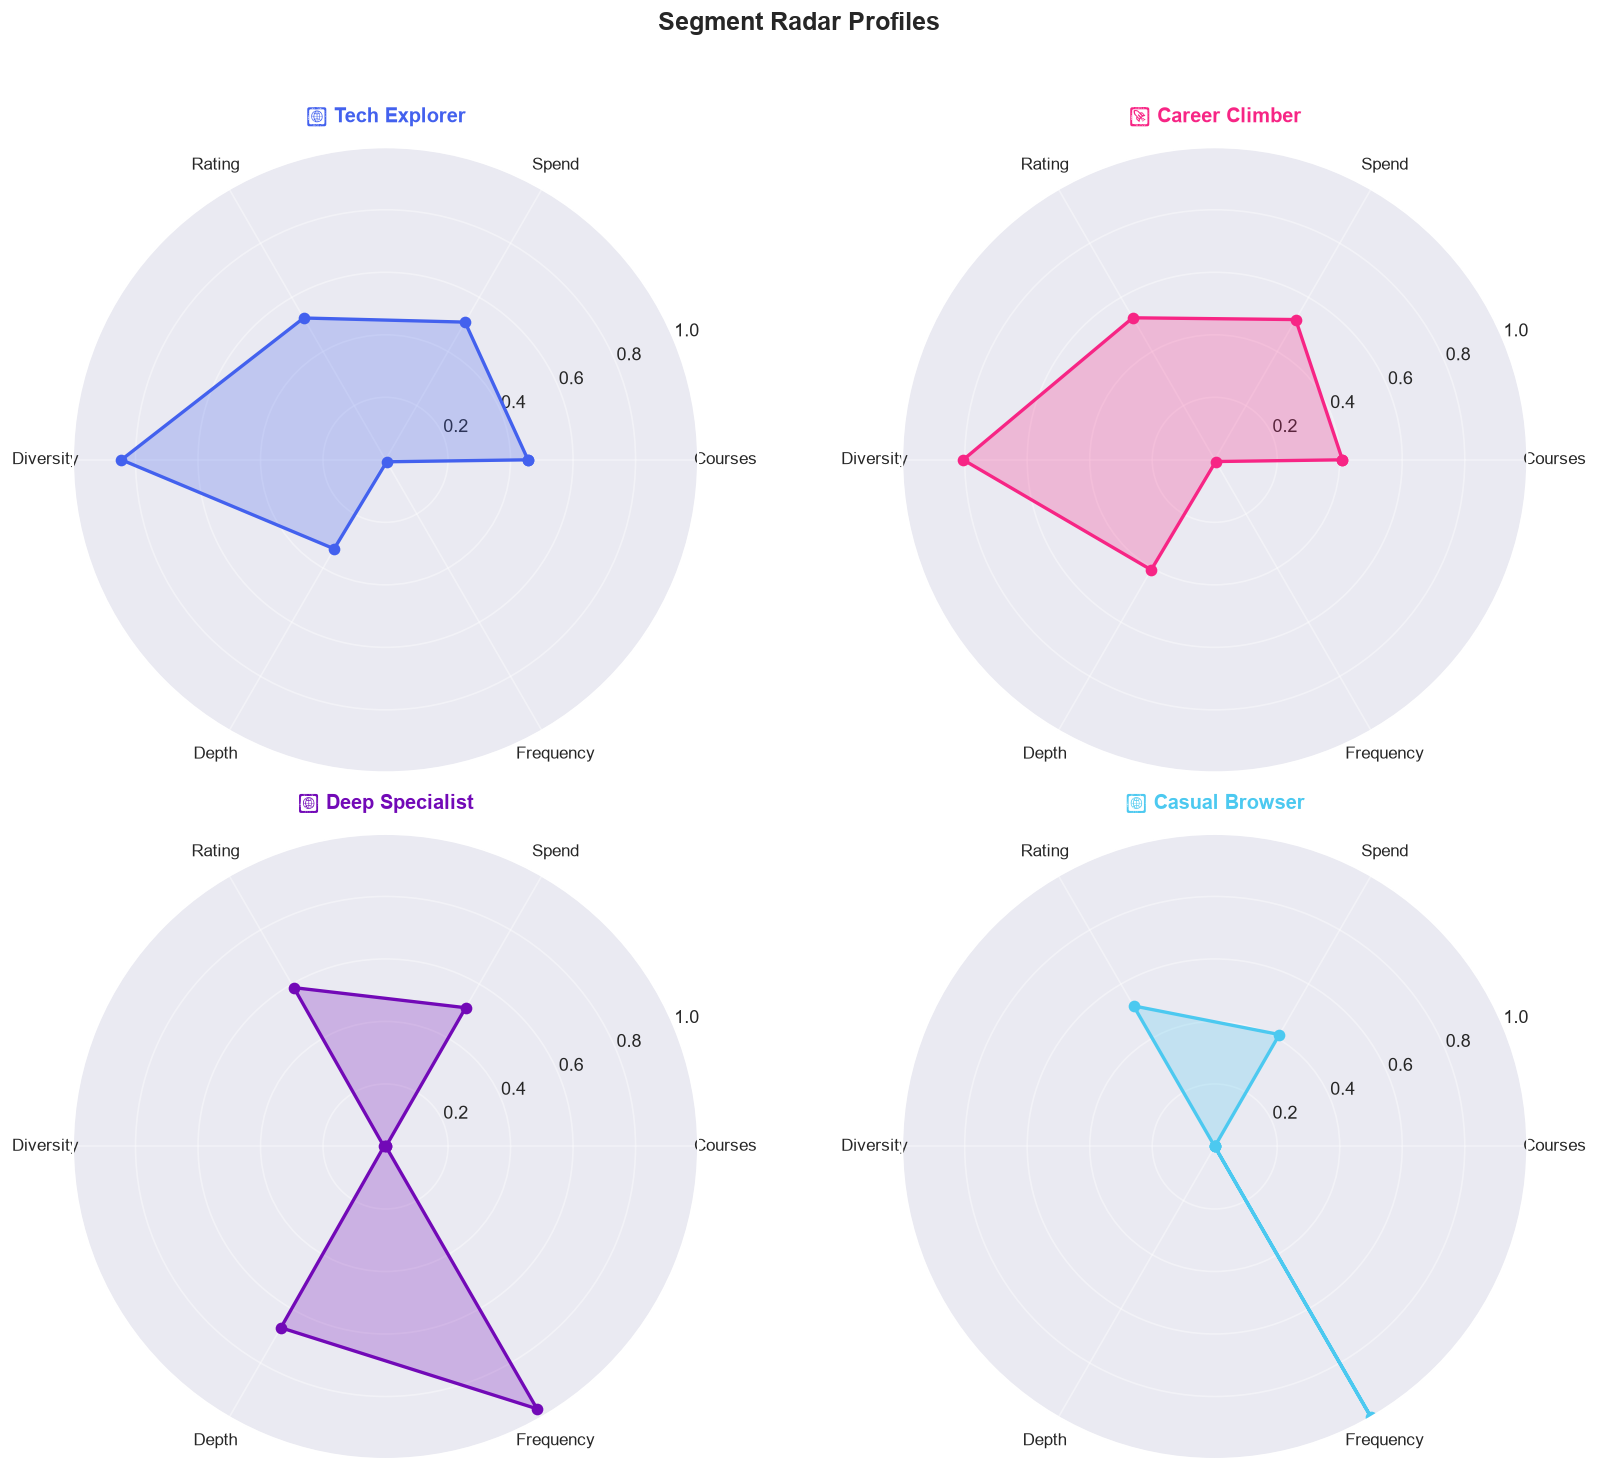

Saved ✅


In [34]:
# Final summary table — this is what you show to stakeholders

summary_features = [
    'total_courses', 'avg_spending', 'total_spending',
    'avg_course_rating', 'learning_depth_index',
    'n_categories', 'enrollment_frequency', 'recency_days'
]

summary = profiles.groupby('SegmentName')[summary_features].mean().round(2)
summary.insert(0, 'n_users',
               profiles.groupby('SegmentName')['UserID'].count())

print("=" * 70)
print("   FINAL SEGMENT SUMMARY")
print("=" * 70)
print(summary.T.to_string())

# Radar Chart — one per segment
fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

radar_features = [
    'total_courses', 'avg_spending', 'avg_course_rating',
    'diversity_score', 'learning_depth_index', 'enrollment_frequency'
]
radar_labels = [
    'Courses', 'Spend', 'Rating',
    'Diversity', 'Depth', 'Frequency'
]
N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, (cluster_id, seg_name) in enumerate(SEGMENT_NAMES.items()):
    seg_data = profiles[profiles['Cluster'] == cluster_id]
    vals     = []
    for f in radar_features:
        mn, mx = profiles[f].min(), profiles[f].max()
        norm   = (seg_data[f].mean() - mn) / (mx - mn + 1e-9)
        vals.append(norm)
    vals += vals[:1]

    axes[idx].plot(angles, vals, 'o-', linewidth=2,
                   color=COLORS[cluster_id])
    axes[idx].fill(angles, vals, alpha=0.25,
                   color=COLORS[cluster_id])
    axes[idx].set_xticks(angles[:-1])
    axes[idx].set_xticklabels(radar_labels, fontsize=10)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_title(seg_name, fontsize=12,
                        fontweight='bold', pad=15,
                        color=COLORS[cluster_id])
    axes[idx].grid(True, alpha=0.4)

plt.suptitle('Segment Radar Profiles',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/13_radar_profiles.png', dpi=150)
plt.show()
print("Saved ✅")

In [ ]:
# ── Create output directories ─────────────────
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/outputs', exist_ok=True)

# ── Save ML Models ────────────────────────────
joblib.dump(km_final, '../models/kmeans_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')
joblib.dump(pca,      '../models/pca_model.pkl')

# ── Save Cluster Labels ───────────────────────
profiles.to_csv('../data/outputs/cluster_labels.csv', index=False)

# ── Save Segment Summary ──────────────────────
summary.to_csv('../data/outputs/segment_summary.csv')


print()
print("Models saved:")
print("  models/kmeans_model.pkl  ✅")
print("  models/scaler.pkl        ✅")
print("  models/pca_model.pkl     ✅")
print()
print("Data saved:")
print("  data/outputs/cluster_labels.csv   ✅")
print("  data/outputs/segment_summary.csv  ✅")
print()
print("Charts saved:")
for i in range(10, 14):
    print(f"  reports/figures/{i}_*.png  ✅")
print()
print(f"Overall Silhouette Score : {overall_sil:.4f}")
print()
print("Segment Summary:")
for seg_id, seg_name in SEGMENT_NAMES.items():
    count = (profiles['Cluster'] == seg_id).sum()
    pct   = count / len(profiles) * 100
    print(f"  {seg_name:<25} : {count:>5} users ({pct:.1f}%)")
print()


   DAY 3 COMPLETE — ALL FILES SAVED

Models saved:
  models/kmeans_model.pkl  ✅
  models/scaler.pkl        ✅
  models/pca_model.pkl     ✅

Data saved:
  data/outputs/cluster_labels.csv   ✅
  data/outputs/segment_summary.csv  ✅

Charts saved:
  reports/figures/10_*.png  ✅
  reports/figures/11_*.png  ✅
  reports/figures/12_*.png  ✅
  reports/figures/13_*.png  ✅

Overall Silhouette Score : 0.2300

Segment Summary:
  🔭 Tech Explorer           :   733 users (60.3%)
  🚀 Career Climber          :   431 users (35.4%)
  📚 Deep Specialist         :    28 users (2.3%)
  🌿 Casual Browser          :    24 users (2.0%)

